In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\alexa\\Desktop\\customer-churn-prediction\\data\\raw\\telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
def basic_audit(df, name="dataset"):
    
    print(f"===== {name.upper()} =====")
    
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    
    print("\nData types:")
    display(df.dtypes.to_frame("data_type"))
    
    # Unified missing values report (NaN + empty strings)
    print("\nMissing values:")
    
    nan_count = df.isna().sum()
    
    empty_count = pd.Series(0, index=df.columns)
    for col in df.select_dtypes(include="object").columns:
        empty_count[col] = (df[col].str.strip() == "").sum()
    
    missing_report = (
        pd.DataFrame({
            "missing_count": nan_count + empty_count,
        })
        .assign(
            missing_percentage=lambda x: (
                100 * x["missing_count"] / len(df)
            ).round(2)
        )
        .sort_values(by="missing_count", ascending=False)
    )
    
    display(missing_report)
    
    print(f"\nDuplicate rows: {df.duplicated().sum():,}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

basic_audit(df, "telco_churn")

===== TELCO_CHURN =====
Rows: 7,043
Columns: 21

Data types:


,data_type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Missing values:


C:\Users\alexa\AppData\Local\Temp\ipykernel_25616\172017662.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,missing_count,missing_percentage
TotalCharges,11,0.16
gender,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
customerID,0,0.00
Dependents,0,0.00
tenure,0,0.00
MultipleLines,0,0.00
PhoneService,0,0.00
OnlineSecurity,0,0.00



Duplicate rows: 0
Memory usage: 6.82 MB


In [25]:
# Cuántos valores son espacios vacíos en TotalCharges
mask = df["TotalCharges"].str.strip() == ""
print(f"Espacios vacíos en TotalCharges: {mask.sum()}")

# Ver esas filas
df[mask]

Espacios vacíos en TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [26]:
# ============================================================
# 3. MISSING VALUES — INVESTIGATION
# ============================================================
#
# TotalCharges contains 11 hidden empty strings (not NaN).
# All 11 missing values occur exclusively among customers 
# with tenure = 0, indicating a deterministic relationship
# between missingness and tenure → classified as MAR.
# ============================================================

mask = df["TotalCharges"].str.strip() == ""
print(f"Records with empty TotalCharges: {mask.sum()}")
print(f"\nTenure values for missing records:")
print(df[mask]["tenure"].value_counts())

Records with empty TotalCharges: 11

Tenure values for missing records:
tenure
0    11
Name: count, dtype: int64


In [27]:
# ============================================================
# 4. HANDLING MISSING VALUES — DROP
# ============================================================
#
# Decision: drop the 11 records.
# Since tenure = 0 does not guarantee a completed billing cycle,
# imputing TotalCharges = MonthlyCharges would be an assumption.
# At 0.16% of the dataset, dropping has negligible impact.
# ============================================================

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).copy()

print(f"Rows after drop: {df.shape[0]:,}")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

Rows after drop: 7,032
TotalCharges dtype: float64


In [28]:
df[df["tenure"] == 0][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges


In [29]:
basic_audit(df, "telco_churn_clean")

===== TELCO_CHURN_CLEAN =====
Rows: 7,032
Columns: 21

Data types:


,data_type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Missing values:


C:\Users\alexa\AppData\Local\Temp\ipykernel_25616\172017662.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,missing_count,missing_percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0



Duplicate rows: 0
Memory usage: 6.55 MB


In [30]:
# Distribución del target
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Distribución de Churn:")
print(pd.DataFrame({"count": churn_counts, "percentage": churn_pct.round(2)}))

Distribución de Churn:
       count  percentage
Churn                   
No      5163       73.42
Yes     1869       26.58


In [31]:
# ============================================================
#  PRIMARY KEY VALIDATION: CUSTOMERID
# ============================================================
#
# Summary:
# This section verifies whether customerID can be used as a
# unique identifier for each customer in the dataset.
#
# The validation checks:
# - Missing customer IDs.
# - Duplicate customer IDs.
# - Consistency between the number of unique IDs and rows.
#
# A valid primary key should uniquely identify each record.
# ============================================================

# Missing IDs
missing_ids = df["customerID"].isna().sum()

# Duplicate IDs
duplicate_ids = df["customerID"].duplicated().sum()

# Unique IDs
unique_ids = df["customerID"].nunique()

# Total rows
total_rows = len(df)

print(f"Missing customer IDs: {missing_ids}")
print(f"Duplicate customer IDs: {duplicate_ids}")
print(f"Unique customer IDs: {unique_ids}")
print(f"Total rows: {total_rows}")

Missing customer IDs: 0
Duplicate customer IDs: 0
Unique customer IDs: 7032
Total rows: 7032


In [32]:
# ============================================================
# 5. NUMERICAL VARIABLES — DESCRIPTIVE STATISTICS
# ============================================================

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


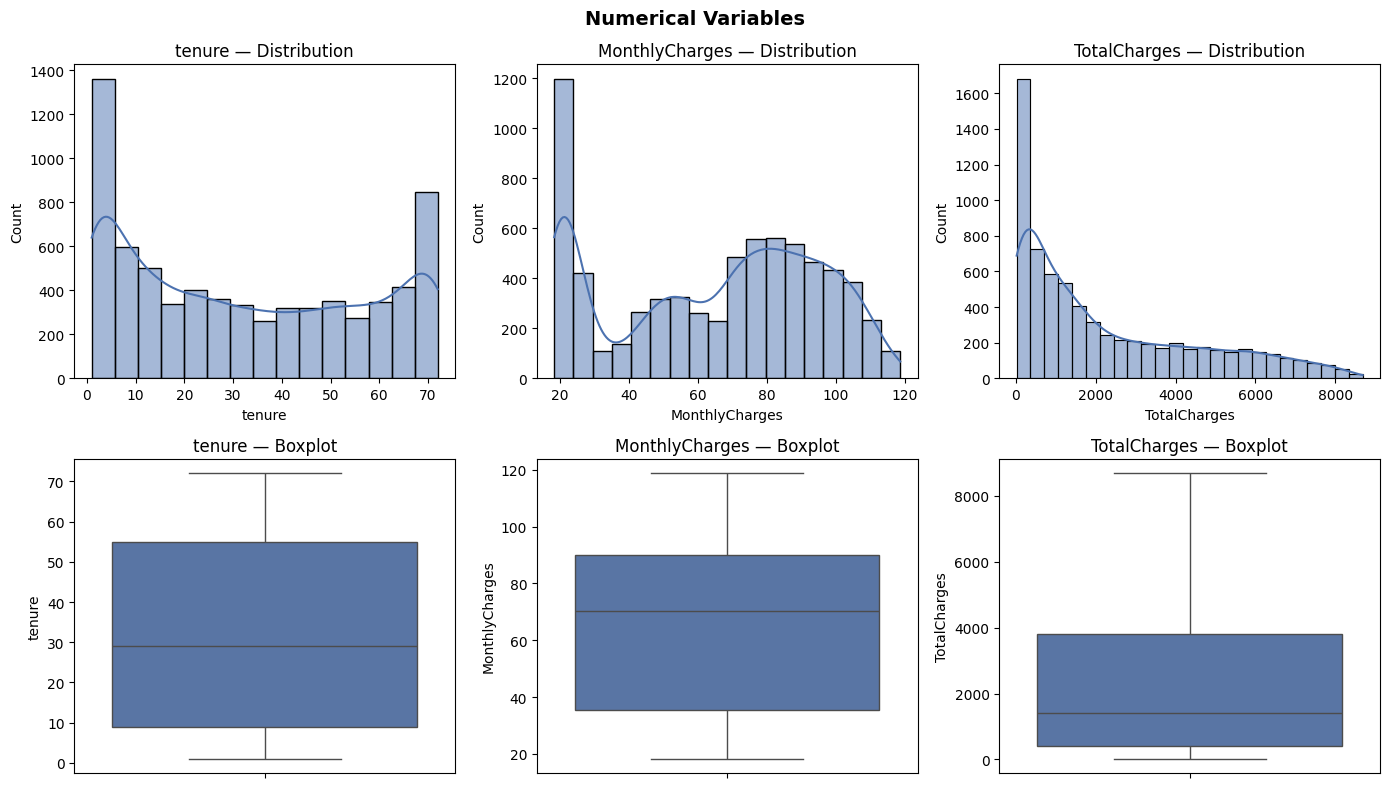

In [33]:
# ============================================================
#  NUMERICAL VARIABLES — DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(df[col], ax=axes[0, i], kde=True, color="#4C72B0")
    axes[0, i].set_title(f"{col} — Distribution")
    
    # Boxplot
    sns.boxplot(y=df[col], ax=axes[1, i], color="#4C72B0")
    axes[1, i].set_title(f"{col} — Boxplot")

plt.suptitle("Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/02_numerical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# ============================================================
# OUTLIER DETECTION — IQR METHOD
# ============================================================
#
# An outlier is defined as a value below Q1 - 1.5*IQR
# or above Q3 + 1.5*IQR
# ============================================================

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}:")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outliers: {len(outliers)} ({100*len(outliers)/len(df):.2f}%)")
    print()

tenure:
  Lower bound: -60.00
  Upper bound: 124.00
  Outliers: 0 (0.00%)

MonthlyCharges:
  Lower bound: -45.82
  Upper bound: 171.27
  Outliers: 0 (0.00%)

TotalCharges:
  Lower bound: -4688.48
  Upper bound: 8884.67
  Outliers: 0 (0.00%)



C:\Users\alexa\AppData\Local\Temp\ipykernel_25616\3422183015.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],
C:\Users\alexa\AppData\Local\Temp\ipykernel_25616\3422183015.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],
C:\Users\alexa\AppData\Local\Temp\ipykernel_25616\3422183015.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],


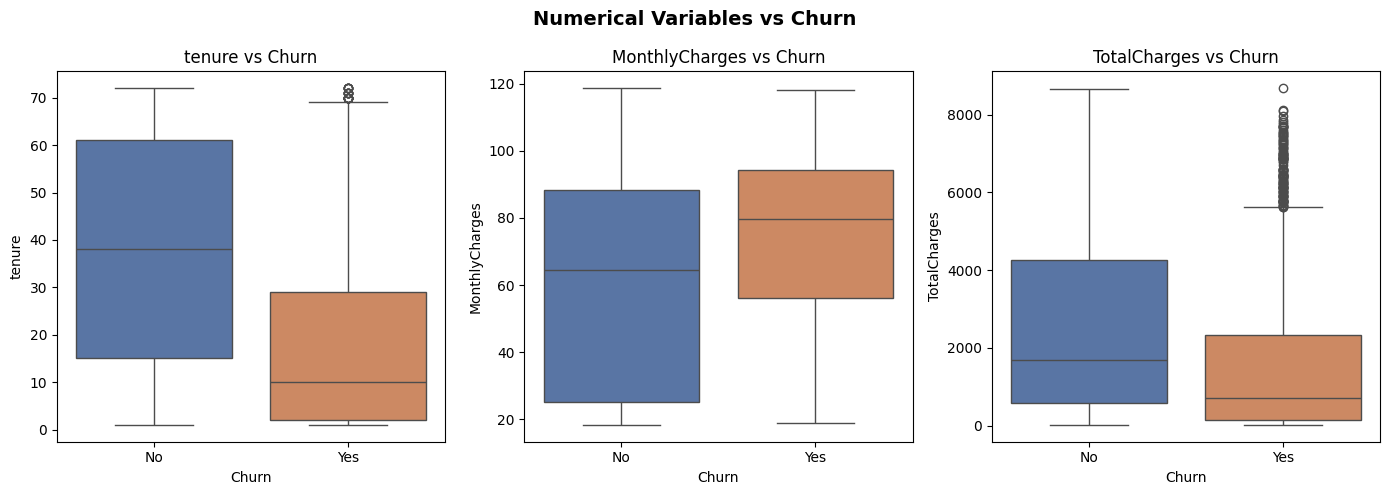

In [ ]:
# ============================================================
# 9. NUMERICAL VARIABLES vs CHURN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],
                palette={"No": "#4C72B0", "Yes": "#DD8452"})
    axes[i].set_title(f"{col} vs Churn")

plt.suptitle("Numerical Variables vs Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/03_numerical_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

The boxplots reveal clear differences between churned and retained customers.

Customers who churn generally exhibit much lower tenure, suggesting that newer customers are at greater risk of leaving the service. Monthly charges also tend to be higher among churned customers, indicating that pricing may influence customer retention.

Although retained customers show higher total charges, this relationship is likely driven by tenure, as longer-standing customers naturally accumulate larger total payments over time.

Several outliers appear in TotalCharges within the churned customer group 
when applying the IQR rule at the group level. These represent customers 
who had accumulated high total charges before eventually leaving the service. 
Since no outliers were detected at the dataset level, and these values are 
consistent with legitimate business behavior, they were retained for analysis.

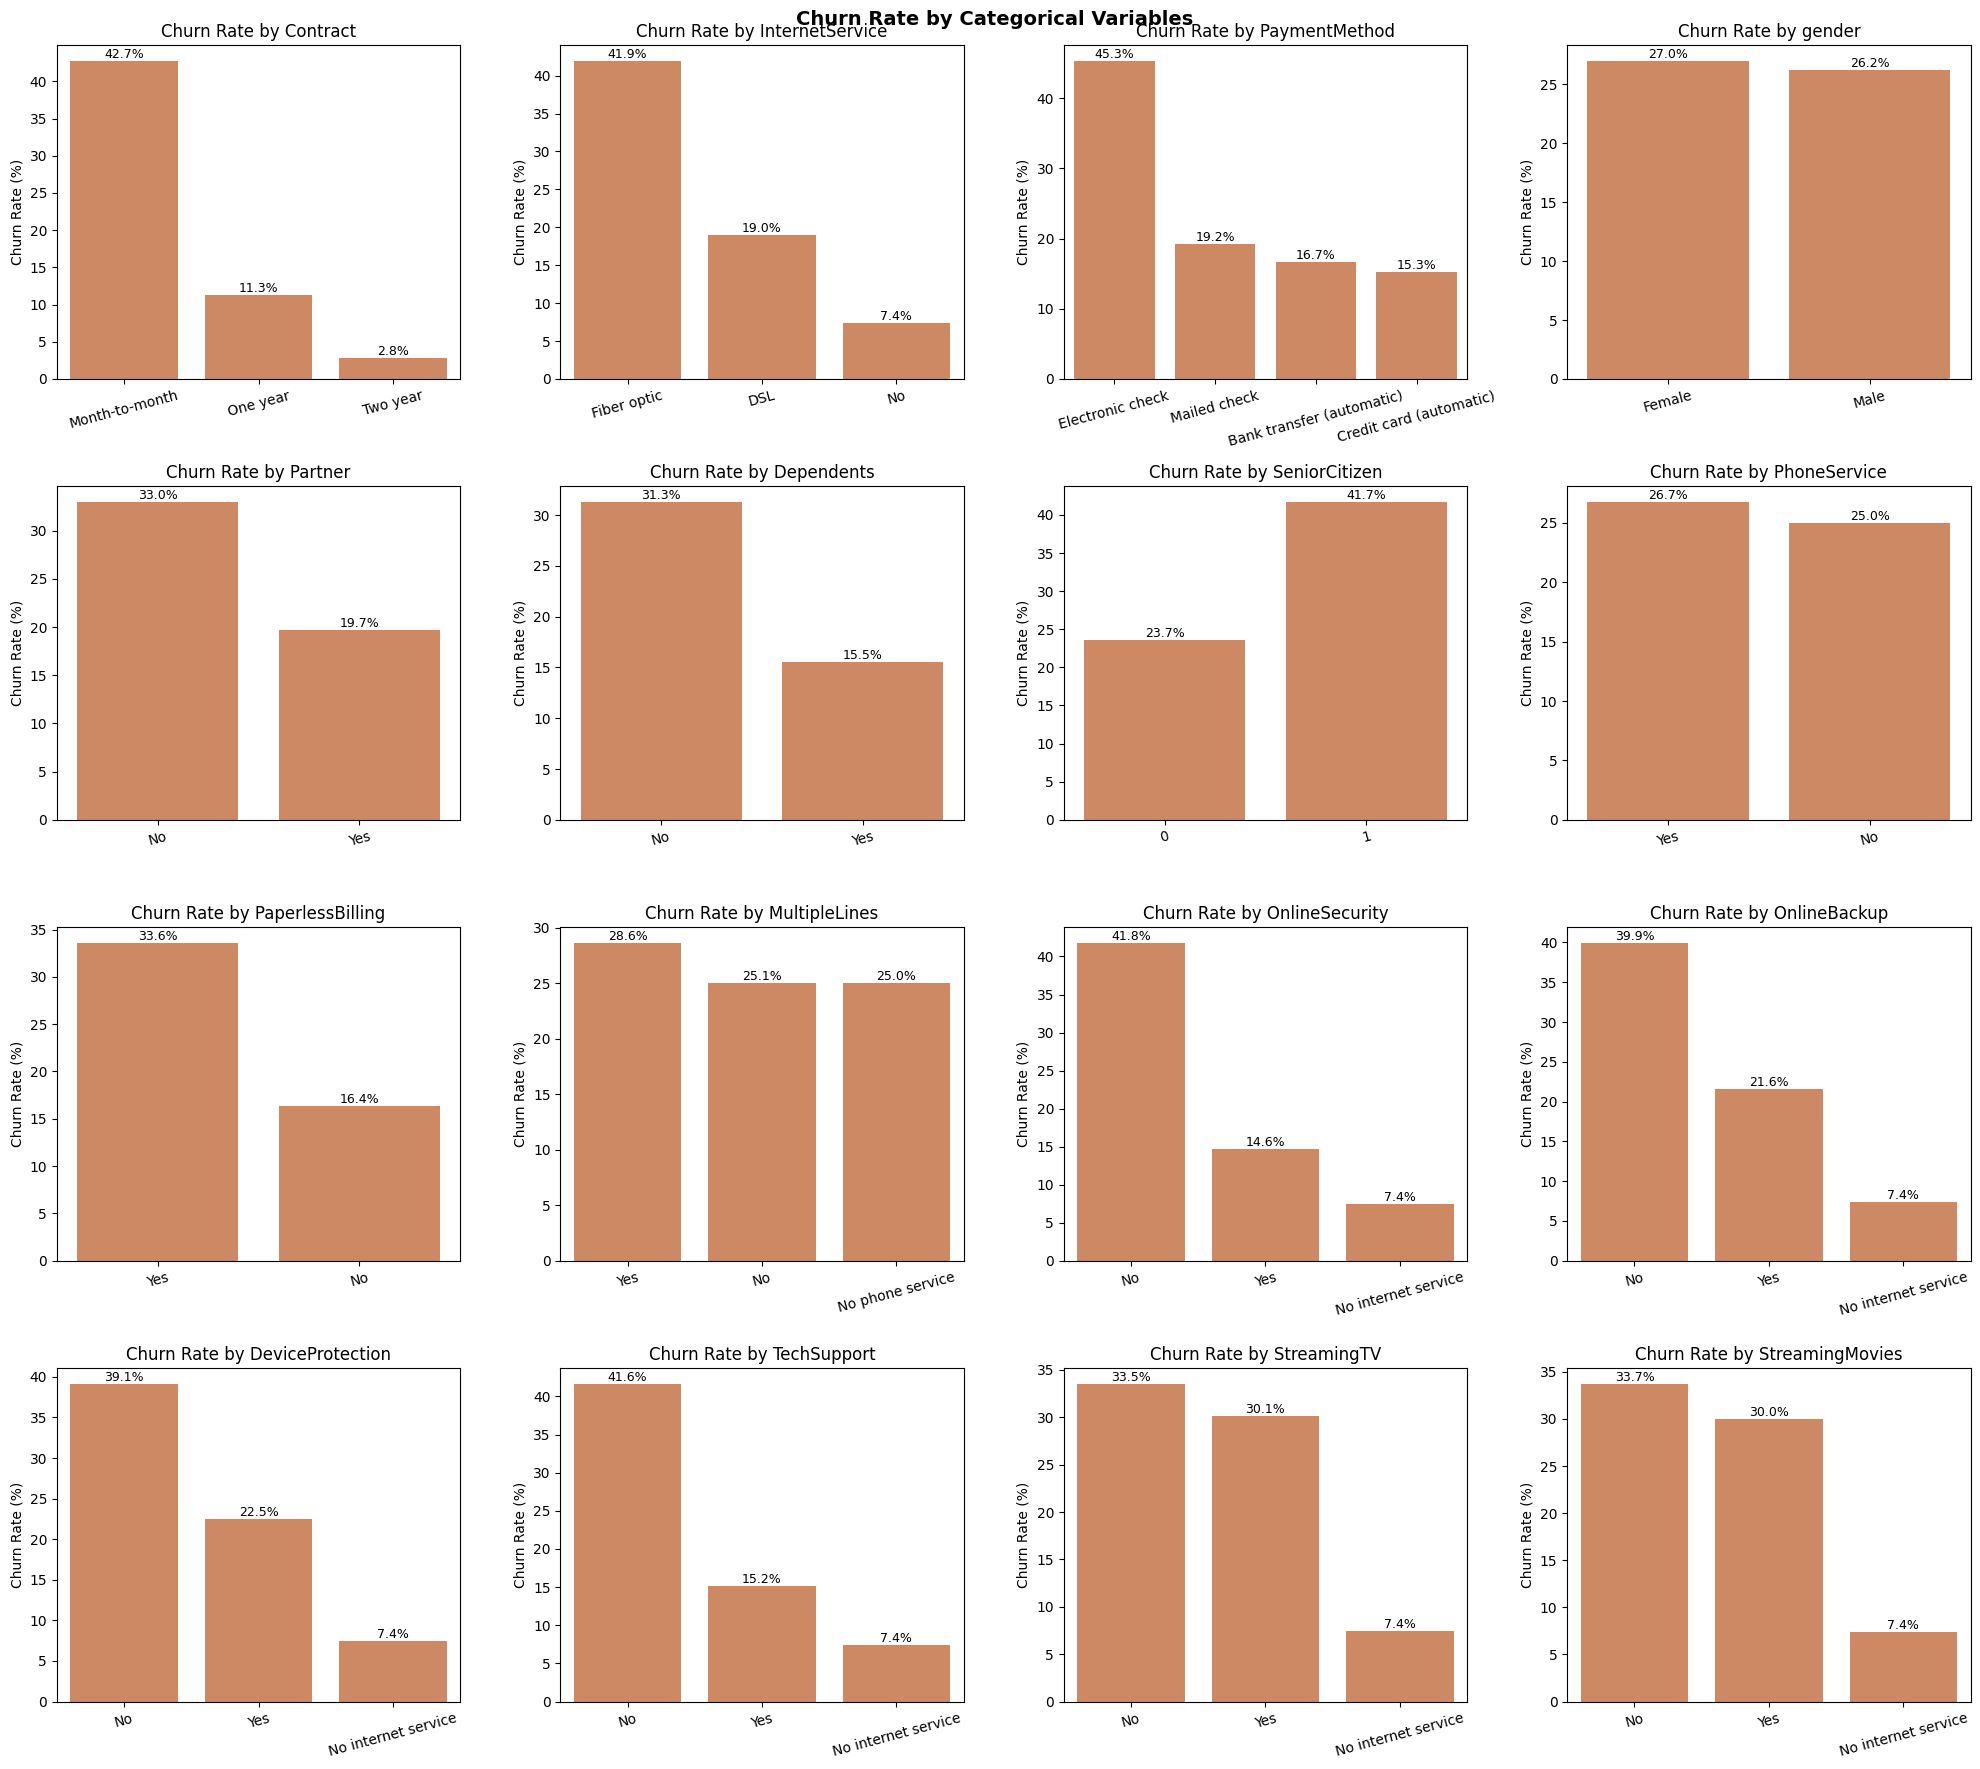

In [42]:
# ============================================================
# 10. CATEGORICAL VARIABLES vs CHURN
# ============================================================

cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "gender", "Partner", "Dependents", "SeniorCitizen",
            "PhoneService", "PaperlessBilling", "MultipleLines",
            "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
        .rename(columns={"Churn": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )
    
    sns.barplot(data=churn_rate, x=col, y="churn_rate",
                ax=axes[i], color="#DD8452")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)
    
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

plt.suptitle("Churn Rate by Categorical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/04_categorical_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()